In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

### Early Stopping (versione semplice)

Implementazione minimalista: si ferma quando la validation loss smette di migliorare.

In [2]:
class SimpleEarlyStopping:
    """Versione semplice: si ferma appena la validation loss smette di migliorare."""
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = None
        self.counter = 0
        self.should_stop = False
    
    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            print(f"📊 Best val loss: {val_loss:.4f}")
        elif val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            print(f"✓ Migliorato! New best: {val_loss:.4f}")
        else:
            self.counter += 1
            print(f"⚠️ Nessun miglioramento ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.should_stop = True
                print(f"🛑 STOP! Nessun miglioramento per {self.patience} epoche")

print("✓ Classe SimpleEarlyStopping pronta!")

✓ Classe SimpleEarlyStopping pronta!


In [7]:
# Usa MPS per Mac (Apple Silicon) o CPU come fallback
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✓ Using MPS (Metal Performance Shaders) - Apple GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✓ Using CUDA - NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("✓ Using CPU")

learning_rate1 = 0.01
learning_rate2 = 0.1
learning_rate3 = 1

✓ Using MPS (Metal Performance Shaders) - Apple GPU


### Architettura MLP (classical Multilayer Perception)

In [10]:
# define neural network: Architecture MLP (classical Multilayer Perception)
class NeuralNetwork(nn.Module):
    def __init__(self, n1, n2, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()

        self.lin1 = nn.Linear(28*28, n1)
        self.act1 = nn.ReLU()

        self.lin2 = nn.Linear(n1, n2)
        self.act2 = nn.ReLU()

        self.output_layer = nn.Linear(n2, num_classes)

    def forward(self, x):
        x = self.flatten(x)  # (batch_size, 28, 28) => (batch_size, 28*28)

        # first layer (input is x, output is x1)
        x1 = self.lin1(x)
        x1 = self.act1(x1)

        # second layer (input is x1, output is x2)
        x2 = self.lin2(x1)
        x2 = self.act2(x2)

        # third/output layer (input is x2, output is logits)
        logits = self.output_layer(x2)
        return logits


In [23]:
from torchvision import datasets, transforms

# preprocessing to apply on each data sample:
# 1) convert to tensor
# 2) normalize images
transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,))  # Normalize a tensor image with mean and standard deviation.
        ])

# train dataset
train_dataset = datasets.FashionMNIST('../data', train=True, download=True, transform=transform)
print(f"MNIST train dataset - num samples: {len(train_dataset)}")

# test dataset
test_dataset = datasets.FashionMNIST('../data', train=False, transform=transform)
print(f"MNIST test dataset - num samples: {len(test_dataset)}")

100.0%

100.0%
0.7%
100.0%

100.0%

MNIST train dataset - num samples: 60000
MNIST test dataset - num samples: 10000


In [24]:
from torch.utils.data import random_split

batch_size = 128  # we define here the batch size: number of samples processed before the model is updated

# Splitting training set into train and validation
train_size = int(0.9 * len(train_dataset))  # 90% for training
val_size = len(train_dataset) - train_size   # 10% for validation

# Create train and validation splits
train_dataset_split, val_dataset = random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # for reproducibility
)

print(f"Training set size: {len(train_dataset_split)}")
print(f"Validation set size: {len(val_dataset)}")

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset_split, 
    batch_size=batch_size, 
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

# Keep test loader as is
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)
print(f"Test set size: {len(test_dataset)}")


Training set size: 54000
Validation set size: 6000
Test set size: 10000


Training

In [25]:
# function for training
def train(model, device, train_loader, optimizer, epoch):
    model.train()  # model to train mode
    train_loss = 0

    # ITERATE DATALOADER: train_loader
    for batch_idx, (data, target) in enumerate(train_loader):
        #  SINGLE OPTIMIZATION STEP IS PERFORMED ON A BATCH!
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)

        loss = F.cross_entropy(output, target)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 50 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
    
    # Return average loss
    avg_loss = train_loss / len(train_loader)
    return avg_loss

In [26]:
# test
# function for evaluation
def test(model, device, test_loader, dataset_name="Test"):
    model.eval()  # model to eval
    test_loss = 0
    correct = 0

    # ITERATE DATALOADER: test_loader
    for data, target in test_loader:
        batch_size = data.shape[0]
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += F.cross_entropy(output, target, reduction='sum').item()  # sum up batch loss

        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability

        # sanity check
        pred = pred.view(batch_size)  # [bs,]
        target = target.view(batch_size)  # [bs,]

        # compute prediction ok
        batch_pred_ok = pred.eq(target).sum().item()
        correct += batch_pred_ok

    test_loss /= len(test_loader.dataset)
    num_samples = len(test_loader.dataset)
    test_accuracy = correct / num_samples
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    print(f'\n{dataset_name} set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * test_accuracy:.2f}%)\n')
    return test_loss, (100. * test_accuracy)


In [27]:
learning_rate1 = 0.01
learning_rate2 = 0.1
learning_rate3 = 1

In [29]:
# Usa MPS per Mac (Apple Silicon) o CPU come fallback
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✓ Using MPS (Metal Performance Shaders) - Apple GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✓ Using CUDA - NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("✓ Using CPU")

    
# training hyperparameters
lr = learning_rate1
num_epochs = 30
print(f"lr: {lr}")
print(f"batch size: {batch_size}")
print(f"Num. optimization steps per-epoch: {int(len(train_dataset)/batch_size)}")

#########
# MODEL #
#########
model = NeuralNetwork(n1=512, n2=128, num_classes=10)
model = model.to(device)

#############
# OPTIMIZER #
#############
parameters_to_optimize = model.parameters()
optimizer = optim.SGD(parameters_to_optimize, lr=lr, momentum=0.9)

✓ Using MPS (Metal Performance Shaders) - Apple GPU
lr: 0.01
batch size: 128
Num. optimization steps per-epoch: 468


### Esecuzione del Training 
in base all'architettura determinata

In [30]:
%%time
import matplotlib.pyplot as plt

# Initialize lists to store metrics
train_losses = []
val_losses = []
val_accuracies = []

# Early stopping semplice
early_stop = SimpleEarlyStopping(patience=3)

# Training loop
for epoch in range(1, num_epochs + 1):
    # Train
    train_loss = train(model, device, train_loader, optimizer, epoch)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, val_acc = test(model, device, val_loader, dataset_name="Validation")
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Check early stopping
    early_stop.step(val_loss)
    if early_stop.should_stop:
        break

# Final test
test_loss, test_acc = test(model, device, test_loader, dataset_name="Test")
print(f"Final Test Accuracy: {test_acc:.2f}%")

Train Epoch: 1 [0/54000 (0%)]	Loss: 2.306801
Train Epoch: 1 [6400/54000 (12%)]	Loss: 0.706941
Train Epoch: 1 [6400/54000 (12%)]	Loss: 0.706941
Train Epoch: 1 [12800/54000 (24%)]	Loss: 0.595335
Train Epoch: 1 [12800/54000 (24%)]	Loss: 0.595335
Train Epoch: 1 [19200/54000 (36%)]	Loss: 0.726268
Train Epoch: 1 [19200/54000 (36%)]	Loss: 0.726268
Train Epoch: 1 [25600/54000 (47%)]	Loss: 0.457767
Train Epoch: 1 [25600/54000 (47%)]	Loss: 0.457767
Train Epoch: 1 [32000/54000 (59%)]	Loss: 0.581792
Train Epoch: 1 [32000/54000 (59%)]	Loss: 0.581792
Train Epoch: 1 [38400/54000 (71%)]	Loss: 0.580969
Train Epoch: 1 [38400/54000 (71%)]	Loss: 0.580969
Train Epoch: 1 [44800/54000 (83%)]	Loss: 0.549022
Train Epoch: 1 [44800/54000 (83%)]	Loss: 0.549022
Train Epoch: 1 [51200/54000 (95%)]	Loss: 0.391266
Train Epoch: 1 [51200/54000 (95%)]	Loss: 0.391266

Test set: Average loss: 0.4508, Accuracy: 5030/6000 (84%)


Validation set: Average loss: 0.4508, Accuracy: 5030/6000 (83.83%)

📊 Best val loss: 0.4508
Trai

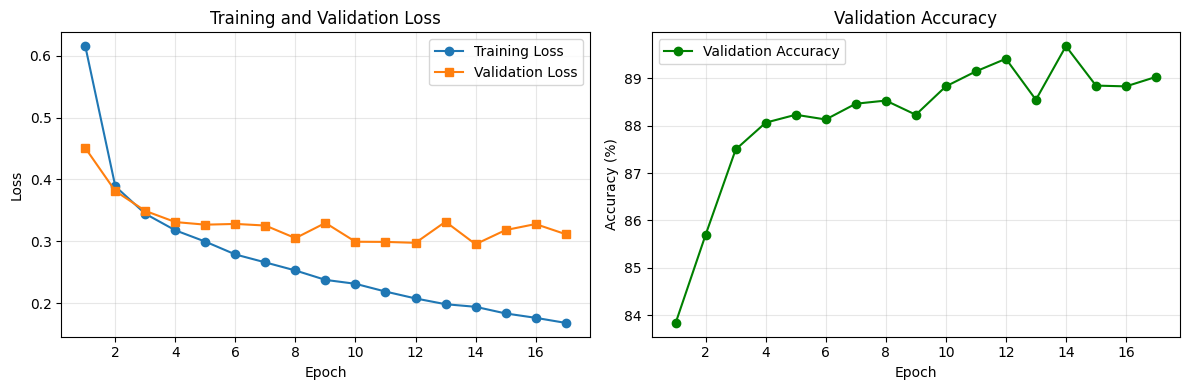

Last epoch (epoch 17) accuracy: 89.03%
⚠️ Warning: Possible overfitting detected!
Recent avg train loss: 0.1845
Recent avg val loss: 0.3171


In [31]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot losses
ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o')
ax1.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
ax2.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy', marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Last epoch (epoch {len(val_accuracies)}) accuracy: {val_accuracies[-1]:.2f}%")

# Check for overfitting
# Serve almeno 6 epoche per fare un'analisi significativa
if len(train_losses) > 5: 
    # Calcola la media delle ultime 5 epoche
    recent_train = np.mean(train_losses[-5:]) 
    recent_val = np.mean(val_losses[-5:])
    # Confronta le due medie 
    if recent_val > recent_train * 1.2:
        print("⚠️ Warning: Possible overfitting detected!")
        print(f"Recent avg train loss: {recent_train:.4f}")
        print(f"Recent avg val loss: {recent_val:.4f}")

### Cambio architettura, uso di una CNN

In [13]:
# Define Convolutional Neural Network
class ConvolutionalNetwork(nn.Module):
    def __init__(self, n1, n2, num_classes):
        super().__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, n1, kernel_size=3, padding=1)  # in_channels=1 for grayscale
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # 2x2 max pooling
        
        self.conv2 = nn.Conv2d(n1, n2, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # 2x2 max pooling
        
        # Calculate the size after convolutions and pooling
        # Input: 28x28 -> after first pool: 14x14 -> after second pool: 7x7
        # So we have n2 channels of 7x7 = n2 * 49
        
        self.flatten = nn.Flatten()
        
        # Fully connected layers (same structure as MLP)
        self.fc1 = nn.Linear(n2 * 7 * 7, n1)
        self.act3 = nn.ReLU()
        
        self.fc2 = nn.Linear(n1, n2)
        self.act4 = nn.ReLU()
        
        self.output_layer = nn.Linear(n2, num_classes)
    
    def forward(self, x):
        # Convolutional part
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)
        
        # Flatten for fully connected layers
        x = self.flatten(x)
        
        # Fully connected part
        x = self.fc1(x)
        x = self.act3(x)
        
        x = self.fc2(x)
        x = self.act4(x)
        
        logits = self.output_layer(x)
        return logits

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create both models with n1=64, n2=128
n1, n2 = 64, 128
num_classes = 10

# MLP
mlp_model = NeuralNetwork(n1=n1, n2=n2, num_classes=num_classes)
mlp_params = count_parameters(mlp_model)

# CNN
cnn_model = ConvolutionalNetwork(n1=n1, n2=n2, num_classes=num_classes)
cnn_params = count_parameters(cnn_model)

print(f"MLP parameters: {mlp_params:,}")
print(f"CNN parameters: {cnn_params:,}")

# Detailed breakdown for MLP
print("\nMLP Detailed:")
print(f"  Layer 1: 28*28 * {n1} + {n1} = {28*28*n1 + n1:,}")
print(f"  Layer 2: {n1} * {n2} + {n2} = {n1*n2 + n2:,}")
print(f"  Output:  {n2} * 10 + 10 = {n2*10 + 10:,}")

# Detailed breakdown for CNN
print("\nCNN Detailed:")
print(f"  Conv1: 1 * {n1} * 3 * 3 + {n1} = {1*n1*3*3 + n1:,}")
print(f"  Conv2: {n1} * {n2} * 3 * 3 + {n2} = {n1*n2*3*3 + n2:,}")
print(f"  FC1:   {n2} * 7 * 7 * {n1} + {n1} = {n2*7*7*n1 + n1:,}")
print(f"  FC2:   {n1} * {n2} + {n2} = {n1*n2 + n2:,}")
print(f"  Output: {n2} * 10 + 10 = {n2*10 + 10:,}")

MLP parameters: 59,850
CNN parameters: 485,578

MLP Detailed:
  Layer 1: 28*28 * 64 + 64 = 50,240
  Layer 2: 64 * 128 + 128 = 8,320
  Output:  128 * 10 + 10 = 1,290

CNN Detailed:
  Conv1: 1 * 64 * 3 * 3 + 64 = 640
  Conv2: 64 * 128 * 3 * 3 + 128 = 73,856
  FC1:   128 * 7 * 7 * 64 + 64 = 401,472
  FC2:   64 * 128 + 128 = 8,320
  Output: 128 * 10 + 10 = 1,290


In [15]:
# Invece di:
# model = NeuralNetwork(n1=512, n2=512, num_classes=10)

# Usa:
model = ConvolutionalNetwork(n1=64, n2=128, num_classes=10)
model = model.to(device)

# Il resto del codice rimane uguale
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

### Esecuzione del Training 
in base all'architettura determinata

In [16]:
%%time
import matplotlib.pyplot as plt

# Initialize lists to store metrics
train_losses = []
val_losses = []
val_accuracies = []

# Early stopping semplice
early_stop = SimpleEarlyStopping(patience=3)

# Training loop
for epoch in range(1, num_epochs + 1):
    # Train
    train_loss = train(model, device, train_loader, optimizer, epoch)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, val_acc = test(model, device, val_loader, dataset_name="Validation")
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Check early stopping
    early_stop.step(val_loss)
    if early_stop.should_stop:
        break

# Final test
test_loss, test_acc = test(model, device, test_loader, dataset_name="Test")
print(f"Final Test Accuracy: {test_acc:.2f}%")

Train Epoch: 1 [0/54000 (0%)]	Loss: 2.304986
Train Epoch: 1 [6400/54000 (12%)]	Loss: 0.583798
Train Epoch: 1 [6400/54000 (12%)]	Loss: 0.583798
Train Epoch: 1 [12800/54000 (24%)]	Loss: 0.197081
Train Epoch: 1 [12800/54000 (24%)]	Loss: 0.197081
Train Epoch: 1 [19200/54000 (36%)]	Loss: 0.145000
Train Epoch: 1 [19200/54000 (36%)]	Loss: 0.145000
Train Epoch: 1 [25600/54000 (47%)]	Loss: 0.148622
Train Epoch: 1 [25600/54000 (47%)]	Loss: 0.148622
Train Epoch: 1 [32000/54000 (59%)]	Loss: 0.132610
Train Epoch: 1 [32000/54000 (59%)]	Loss: 0.132610
Train Epoch: 1 [38400/54000 (71%)]	Loss: 0.147588
Train Epoch: 1 [38400/54000 (71%)]	Loss: 0.147588
Train Epoch: 1 [44800/54000 (83%)]	Loss: 0.113547
Train Epoch: 1 [44800/54000 (83%)]	Loss: 0.113547
Train Epoch: 1 [51200/54000 (95%)]	Loss: 0.073496
Train Epoch: 1 [51200/54000 (95%)]	Loss: 0.073496

Test set: Average loss: 0.1044, Accuracy: 5817/6000 (97%)


Validation set: Average loss: 0.1044, Accuracy: 5817/6000 (96.95%)

📊 Best val loss: 0.1044
Trai

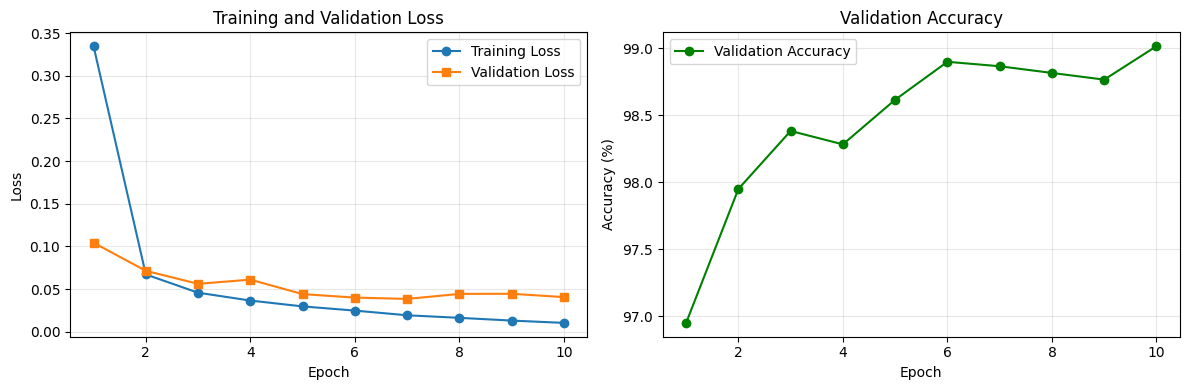

⚠️ Warning: Possible overfitting detected!
Recent avg train loss: 0.0169
Recent avg val loss: 0.0417


In [17]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot losses
ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o')
ax1.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
ax2.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy', marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for overfitting
if len(train_losses) > 5:
    recent_train = np.mean(train_losses[-5:])
    recent_val = np.mean(val_losses[-5:])
    if recent_val > recent_train * 1.2:
        print("⚠️ Warning: Possible overfitting detected!")
        print(f"Recent avg train loss: {recent_train:.4f}")
        print(f"Recent avg val loss: {recent_val:.4f}")

### MLP con Dropout + Weight Decay (famiglia Regolarizzazione)

Implementazione di tecniche di regolarizzazione per ridurre overfitting:
- **Dropout**: disattiva casualmente neuroni durante il training (default 50%)
- **Weight Decay**: aggiunge penalizzazione L2 ai pesi nell'optimizer

1️⃣ RegularizedNeuralNetwork Class
MLP con Dropout dopo ogni layer (default 50%)
Stessa architettura del modello originale (512-128-10)
Dropout si disattiva automaticamente in modalità evaluation

2️⃣ Training con Regolarizzazione
Weight Decay = 1e-4 nell'optimizer (L2 regularization)
Dropout Rate = 0.5 (50% dei neuroni disattivati)
Early Stopping con pazienza aumentata a 5 epoche
Monitoraggio completo di train/val loss e accuracy

3️⃣ Confronto Diretto
4 grafici comparativi:
Training Loss
Validation Loss
Validation Accuracy
Overfitting Gap (Val Loss - Train Loss)
Tabella riassuntiva con metriche chiave
Analisi automatica del miglioramento

4️⃣ Esperimenti con Diversi Dropout
Test sistematico di 5 valori: [0.0, 0.2, 0.3, 0.5, 0.7]
Per ogni valore:
Training completo (max 20 epoche)
Early stopping
Valutazione su test set
Visualizzazione risultati e raccomandazioni

🎯 Come Usare:
Esegui prima le celle iniziali (import, data loading, funzioni train/test)
Esegui il training MLP standard (celle 12-15)
Esegui le nuove celle alla fine per vedere:
MLP regolarizzato singolo
Confronto con il modello standard
(Opzionale) Esperimenti con diversi dropout rates
🔍 Cosa Aspettarsi:
Con Dropout + Weight Decay dovresti vedere:

✅ Riduzione dell'overfitting gap
✅ Migliore generalizzazione (test accuracy più vicina a validation)
⚠️ Possibile training loss più alta (normale con dropout)
⚠️ Possibile convergenza più lenta (compensata da early stopping)

In [32]:
# MLP with Dropout and Weight Decay
class RegularizedNeuralNetwork(nn.Module):
    def __init__(self, n1, n2, num_classes, dropout_rate=0.5):
        super().__init__()
        self.flatten = nn.Flatten()

        # First layer
        self.lin1 = nn.Linear(28*28, n1)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout_rate)  # Dropout dopo prima attivazione

        # Second layer
        self.lin2 = nn.Linear(n1, n2)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_rate)  # Dropout dopo seconda attivazione

        # Output layer
        self.output_layer = nn.Linear(n2, num_classes)

    def forward(self, x):
        x = self.flatten(x)

        # First layer with dropout
        x1 = self.lin1(x)
        x1 = self.act1(x1)
        x1 = self.dropout1(x1)  # Dropout attivo solo in training mode

        # Second layer with dropout
        x2 = self.lin2(x1)
        x2 = self.act2(x2)
        x2 = self.dropout2(x2)

        # Output layer (no dropout)
        logits = self.output_layer(x2)
        return logits

print("✓ Classe RegularizedNeuralNetwork con Dropout pronta!")

✓ Classe RegularizedNeuralNetwork con Dropout pronta!


In [40]:
# Hyperparameters for regularized MLP
dropout_rate = 0.2 #  # 50% dei neuroni disattivati durante training
weight_decay = 1e-4  # L2 regularization strength (0.0001)

print(f"Dropout rate: {dropout_rate}")
print(f"Weight decay: {weight_decay}")

# Create regularized model
model_reg = RegularizedNeuralNetwork(n1=512, n2=128, num_classes=10, dropout_rate=dropout_rate)
model_reg = model_reg.to(device)

# Optimizer with weight decay (L2 regularization)
optimizer_reg = optim.SGD(
    model_reg.parameters(), 
    lr=learning_rate1, 
    momentum=0.9,
    weight_decay=weight_decay  # Aggiunge penalizzazione L2
)

print(f"\n✓ Model parameters: {sum(p.numel() for p in model_reg.parameters()):,}")
print(f"✓ Learning rate: {learning_rate1}")
print(f"✓ Momentum: 0.9")
print(f"✓ Weight decay (L2): {weight_decay}")

Dropout rate: 0.2
Weight decay: 0.0001

✓ Model parameters: 468,874
✓ Learning rate: 0.01
✓ Momentum: 0.9
✓ Weight decay (L2): 0.0001


### Training MLP Regolarizzato

Training con Dropout + Weight Decay + Early Stopping

In [41]:
%%time
import matplotlib.pyplot as plt

# Initialize lists to store metrics
train_losses_reg = []
val_losses_reg = []
val_accuracies_reg = []

# Early stopping
early_stop_reg = SimpleEarlyStopping(patience=5)  # Pazienza aumentata con regularization

# Training loop
for epoch in range(1, num_epochs + 1):
    # Train
    train_loss = train(model_reg, device, train_loader, optimizer_reg, epoch)
    train_losses_reg.append(train_loss)
    
    # Validate
    val_loss, val_acc = test(model_reg, device, val_loader, dataset_name="Validation")
    val_losses_reg.append(val_loss)
    val_accuracies_reg.append(val_acc)
    
    # Check early stopping
    early_stop_reg.step(val_loss)
    if early_stop_reg.should_stop:
        break

# Final test
test_loss_reg, test_acc_reg = test(model_reg, device, test_loader, dataset_name="Test")
print(f"\n{'='*60}")
print(f"🎯 Final Test Accuracy (Regularized MLP): {test_acc_reg:.2f}%")
print(f"{'='*60}")

Train Epoch: 1 [0/54000 (0%)]	Loss: 2.343510
Train Epoch: 1 [6400/54000 (12%)]	Loss: 0.924684
Train Epoch: 1 [12800/54000 (24%)]	Loss: 0.685948
Train Epoch: 1 [19200/54000 (36%)]	Loss: 0.642893
Train Epoch: 1 [25600/54000 (47%)]	Loss: 0.457229
Train Epoch: 1 [32000/54000 (59%)]	Loss: 0.500867
Train Epoch: 1 [38400/54000 (71%)]	Loss: 0.471906
Train Epoch: 1 [44800/54000 (83%)]	Loss: 0.439099
Train Epoch: 1 [51200/54000 (95%)]	Loss: 0.477423

Test set: Average loss: 0.4376, Accuracy: 5031/6000 (84%)


Validation set: Average loss: 0.4376, Accuracy: 5031/6000 (83.85%)

📊 Best val loss: 0.4376
Train Epoch: 2 [0/54000 (0%)]	Loss: 0.575108
Train Epoch: 2 [6400/54000 (12%)]	Loss: 0.523886
Train Epoch: 2 [12800/54000 (24%)]	Loss: 0.404724
Train Epoch: 2 [19200/54000 (36%)]	Loss: 0.569378
Train Epoch: 2 [25600/54000 (47%)]	Loss: 0.479577
Train Epoch: 2 [32000/54000 (59%)]	Loss: 0.383500
Train Epoch: 2 [38400/54000 (71%)]	Loss: 0.283256
Train Epoch: 2 [44800/54000 (83%)]	Loss: 0.478694
Train Epo

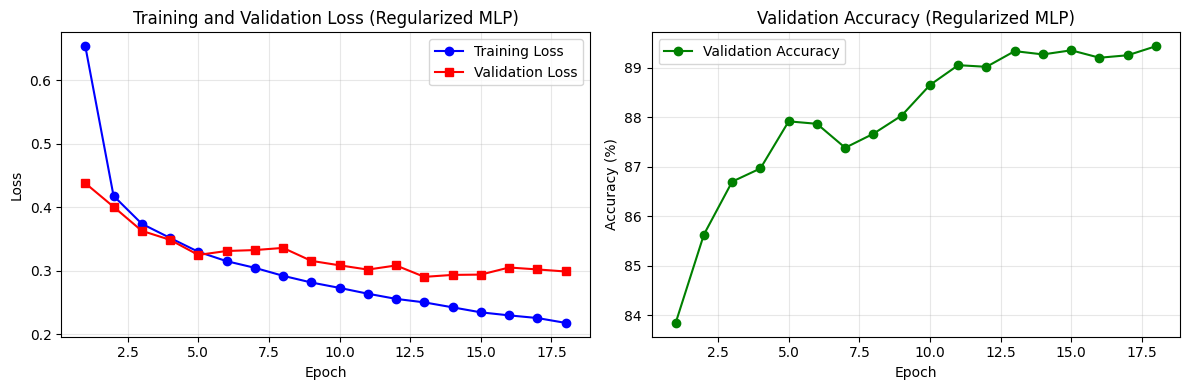


📊 Training Summary:
   Total epochs: 18
   Best validation accuracy: 89.43%
   Final validation accuracy: 89.43%
   Test accuracy: 88.69%

🔍 Overfitting Analysis:
   Recent avg train loss: 0.2297
   Recent avg val loss: 0.2984
   Gap: 0.0687 (29.9%)
   ⚠️ Warning: Possible overfitting detected!


In [42]:
# Plotting - Regularized MLP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot losses
ax1.plot(range(1, len(train_losses_reg) + 1), train_losses_reg, label='Training Loss', marker='o', color='blue')
ax1.plot(range(1, len(val_losses_reg) + 1), val_losses_reg, label='Validation Loss', marker='s', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss (Regularized MLP)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
ax2.plot(range(1, len(val_accuracies_reg) + 1), val_accuracies_reg, label='Validation Accuracy', marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy (Regularized MLP)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Training Summary:")
print(f"   Total epochs: {len(val_accuracies_reg)}")
print(f"   Best validation accuracy: {max(val_accuracies_reg):.2f}%")
print(f"   Final validation accuracy: {val_accuracies_reg[-1]:.2f}%")
print(f"   Test accuracy: {test_acc_reg:.2f}%")

# Check for overfitting
if len(train_losses_reg) > 5:
    recent_train = np.mean(train_losses_reg[-5:])
    recent_val = np.mean(val_losses_reg[-5:])
    gap = recent_val - recent_train
    gap_pct = (gap / recent_train) * 100
    
    print(f"\n🔍 Overfitting Analysis:")
    print(f"   Recent avg train loss: {recent_train:.4f}")
    print(f"   Recent avg val loss: {recent_val:.4f}")
    print(f"   Gap: {gap:.4f} ({gap_pct:.1f}%)")
    
    if recent_val > recent_train * 1.2:
        print("   ⚠️ Warning: Possible overfitting detected!")
    else:
        print("   ✓ Model generalizing well!")

### Confronto: MLP Standard vs MLP Regolarizzato

Confronto delle performance tra il modello originale e quello con Dropout + Weight Decay

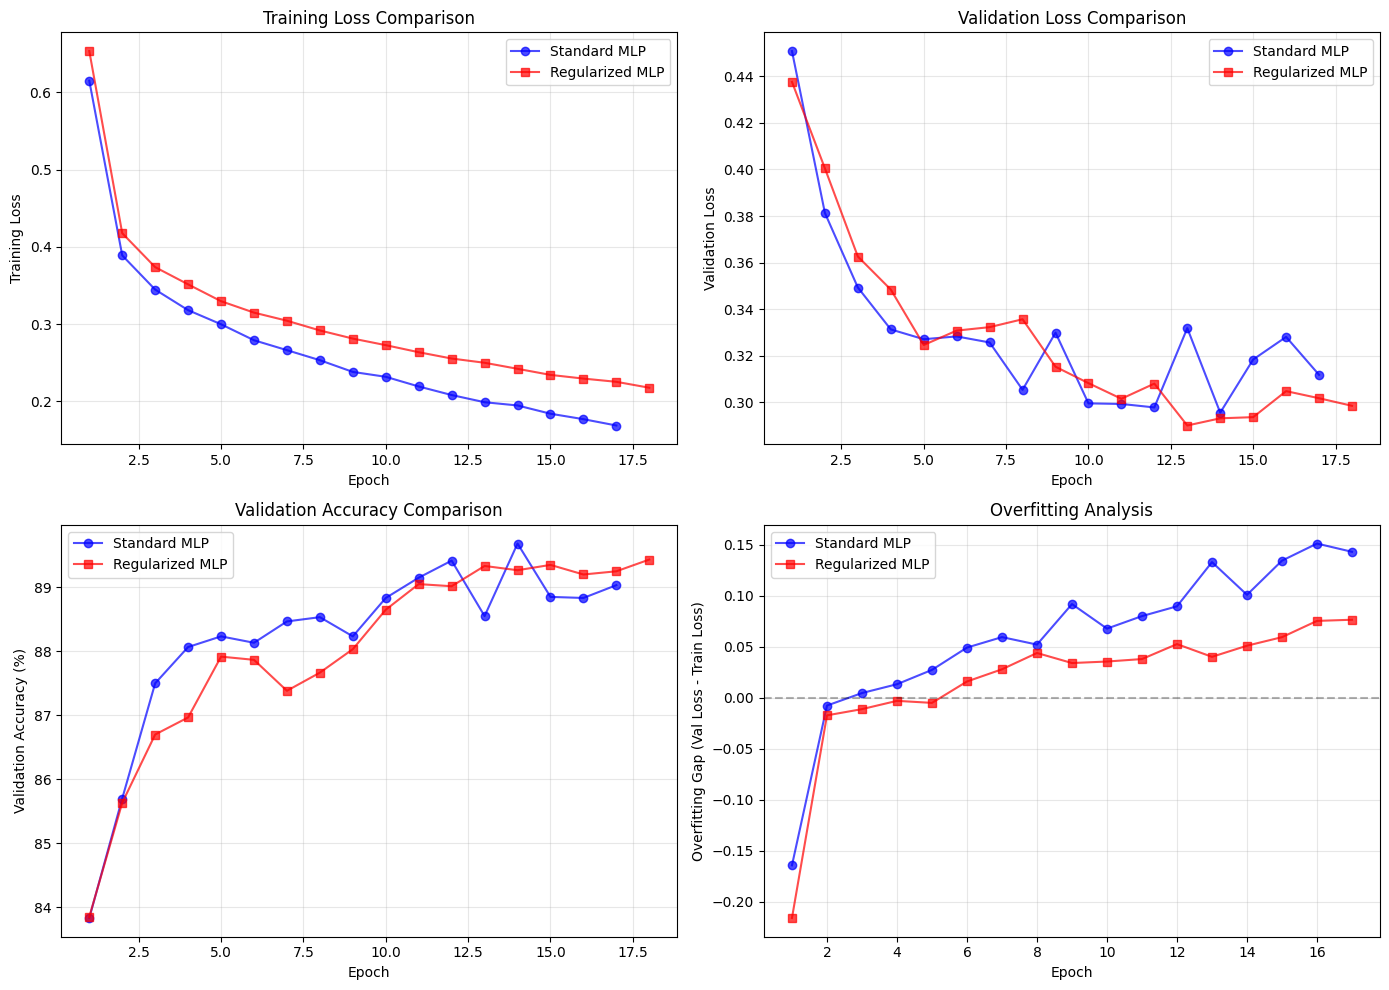


                          COMPARISON SUMMARY                          

Metric                         Standard MLP         Regularized MLP     
----------------------------------------------------------------------
Architecture                   512-128-10           512-128-10 + Dropout
Weight Decay                   No                   Yes (1e-4)          
Dropout Rate                   No                   50%                 
----------------------------------------------------------------------
Total Epochs Trained           17                   18                  
Best Val Accuracy              89.68%                 89.43%
Final Val Accuracy             89.03%                 89.43%
Test Accuracy                  89.16%                 88.69%
----------------------------------------------------------------------
Avg Recent Train Loss          0.1845               0.2297
Avg Recent Val Loss            0.3171               0.2984
Overfitting Gap                0.1326           

In [43]:
# Comparison plot - Standard MLP vs Regularized MLP
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get minimum length for comparison
min_epochs = min(len(train_losses), len(train_losses_reg))

# Plot 1: Training Loss Comparison
axes[0, 0].plot(range(1, len(train_losses) + 1), train_losses, 
                label='Standard MLP', marker='o', alpha=0.7, color='blue')
axes[0, 0].plot(range(1, len(train_losses_reg) + 1), train_losses_reg, 
                label='Regularized MLP', marker='s', alpha=0.7, color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation Loss Comparison
axes[0, 1].plot(range(1, len(val_losses) + 1), val_losses, 
                label='Standard MLP', marker='o', alpha=0.7, color='blue')
axes[0, 1].plot(range(1, len(val_losses_reg) + 1), val_losses_reg, 
                label='Regularized MLP', marker='s', alpha=0.7, color='red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Loss')
axes[0, 1].set_title('Validation Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Validation Accuracy Comparison
axes[1, 0].plot(range(1, len(val_accuracies) + 1), val_accuracies, 
                label='Standard MLP', marker='o', alpha=0.7, color='blue')
axes[1, 0].plot(range(1, len(val_accuracies_reg) + 1), val_accuracies_reg, 
                label='Regularized MLP', marker='s', alpha=0.7, color='red')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Accuracy (%)')
axes[1, 0].set_title('Validation Accuracy Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Overfitting Gap (Val Loss - Train Loss)
gap_standard = [val_losses[i] - train_losses[i] for i in range(min_epochs)]
gap_regularized = [val_losses_reg[i] - train_losses_reg[i] for i in range(min_epochs)]

axes[1, 1].plot(range(1, min_epochs + 1), gap_standard, 
                label='Standard MLP', marker='o', alpha=0.7, color='blue')
axes[1, 1].plot(range(1, min_epochs + 1), gap_regularized, 
                label='Regularized MLP', marker='s', alpha=0.7, color='red')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Overfitting Gap (Val Loss - Train Loss)')
axes[1, 1].set_title('Overfitting Analysis')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary comparison
print(f"\n{'='*70}")
print(f"{'COMPARISON SUMMARY':^70}")
print(f"{'='*70}")
print(f"\n{'Metric':<30} {'Standard MLP':<20} {'Regularized MLP':<20}")
print(f"{'-'*70}")
print(f"{'Architecture':<30} {'512-128-10':<20} {'512-128-10 + Dropout':<20}")
print(f"{'Weight Decay':<30} {'No':<20} {'Yes (1e-4)':<20}")
print(f"{'Dropout Rate':<30} {'No':<20} {'50%':<20}")
print(f"{'-'*70}")
print(f"{'Total Epochs Trained':<30} {len(val_accuracies):<20} {len(val_accuracies_reg):<20}")
print(f"{'Best Val Accuracy':<30} {max(val_accuracies):.2f}%{'':<16} {max(val_accuracies_reg):.2f}%")
print(f"{'Final Val Accuracy':<30} {val_accuracies[-1]:.2f}%{'':<16} {val_accuracies_reg[-1]:.2f}%")
print(f"{'Test Accuracy':<30} {test_acc:.2f}%{'':<16} {test_acc_reg:.2f}%")
print(f"{'-'*70}")

# Calculate overfitting metrics
if len(train_losses) > 5 and len(train_losses_reg) > 5:
    std_train = np.mean(train_losses[-5:])
    std_val = np.mean(val_losses[-5:])
    std_gap = std_val - std_train
    
    reg_train = np.mean(train_losses_reg[-5:])
    reg_val = np.mean(val_losses_reg[-5:])
    reg_gap = reg_val - reg_train
    
    print(f"{'Avg Recent Train Loss':<30} {std_train:.4f}{'':<14} {reg_train:.4f}")
    print(f"{'Avg Recent Val Loss':<30} {std_val:.4f}{'':<14} {reg_val:.4f}")
    print(f"{'Overfitting Gap':<30} {std_gap:.4f}{'':<14} {reg_gap:.4f}")
    print(f"{'Gap Reduction':<30} {'':<20} {((std_gap - reg_gap) / std_gap * 100):.1f}%")
print(f"{'='*70}\n")

# Conclusion
if test_acc_reg > test_acc:
    improvement = test_acc_reg - test_acc
    print(f"✅ Regularized MLP performs BETTER (+{improvement:.2f}%)")
elif test_acc_reg < test_acc:
    decline = test_acc - test_acc_reg
    print(f"⚠️ Regularized MLP performs WORSE (-{decline:.2f}%)")
else:
    print(f"➡️ Both models have similar performance")

if len(train_losses_reg) > 5:
    if reg_gap < std_gap:
        print(f"✅ Regularization REDUCED overfitting gap by {((std_gap - reg_gap) / std_gap * 100):.1f}%")
    else:
        print(f"⚠️ Regularization did not reduce overfitting")

### Esperimenti con Diversi Valori di Dropout

Test di diversi dropout rates per trovare il valore ottimale

In [37]:
# Test different dropout rates
dropout_rates_to_test = [0.0, 0.2, 0.3, 0.5, 0.7]
results = []

print(f"Testing {len(dropout_rates_to_test)} different dropout rates...")
print(f"This may take a few minutes...\n")

for dr in dropout_rates_to_test:
    print(f"\n{'='*60}")
    print(f"Testing Dropout Rate: {dr}")
    print(f"{'='*60}")
    
    # Create model with specific dropout rate
    model_test = RegularizedNeuralNetwork(n1=512, n2=128, num_classes=10, dropout_rate=dr)
    model_test = model_test.to(device)
    
    # Optimizer with weight decay
    optimizer_test = optim.SGD(
        model_test.parameters(), 
        lr=learning_rate1, 
        momentum=0.9,
        weight_decay=1e-4
    )
    
    # Early stopping
    early_stop_test = SimpleEarlyStopping(patience=5)
    
    # Training
    val_accs = []
    train_losses_test = []
    val_losses_test = []
    
    for epoch in range(1, 20 + 1):  # Max 20 epochs per test
        # Train
        train_loss = train(model_test, device, train_loader, optimizer_test, epoch)
        train_losses_test.append(train_loss)
        
        # Validate
        val_loss, val_acc = test(model_test, device, val_loader, dataset_name="Validation")
        val_losses_test.append(val_loss)
        val_accs.append(val_acc)
        
        # Check early stopping
        early_stop_test.step(val_loss)
        if early_stop_test.should_stop:
            break
    
    # Test
    test_loss_test, test_acc_test = test(model_test, device, test_loader, dataset_name="Test")
    
    # Store results
    results.append({
        'dropout_rate': dr,
        'best_val_acc': max(val_accs),
        'final_val_acc': val_accs[-1],
        'test_acc': test_acc_test,
        'epochs': len(val_accs),
        'final_train_loss': train_losses_test[-1],
        'final_val_loss': val_losses_test[-1]
    })
    
    print(f"\n✓ Dropout {dr}: Best Val Acc = {max(val_accs):.2f}%, Test Acc = {test_acc_test:.2f}%")

print(f"\n{'='*60}")
print(f"All tests completed!")
print(f"{'='*60}")

Testing 5 different dropout rates...
This may take a few minutes...


Testing Dropout Rate: 0.0
Train Epoch: 1 [0/54000 (0%)]	Loss: 2.323911
Train Epoch: 1 [6400/54000 (12%)]	Loss: 1.051063
Train Epoch: 1 [12800/54000 (24%)]	Loss: 0.737597
Train Epoch: 1 [19200/54000 (36%)]	Loss: 0.599447
Train Epoch: 1 [25600/54000 (47%)]	Loss: 0.497043
Train Epoch: 1 [32000/54000 (59%)]	Loss: 0.405635
Train Epoch: 1 [38400/54000 (71%)]	Loss: 0.440256
Train Epoch: 1 [44800/54000 (83%)]	Loss: 0.528751
Train Epoch: 1 [51200/54000 (95%)]	Loss: 0.343571

Test set: Average loss: 0.4312, Accuracy: 5053/6000 (84%)


Validation set: Average loss: 0.4312, Accuracy: 5053/6000 (84.22%)

📊 Best val loss: 0.4312
Train Epoch: 2 [0/54000 (0%)]	Loss: 0.414743
Train Epoch: 2 [6400/54000 (12%)]	Loss: 0.479627
Train Epoch: 2 [12800/54000 (24%)]	Loss: 0.364314
Train Epoch: 2 [19200/54000 (36%)]	Loss: 0.431114
Train Epoch: 2 [25600/54000 (47%)]	Loss: 0.470875
Train Epoch: 2 [32000/54000 (59%)]	Loss: 0.398046
Train Epoch: 


📊 Dropout Rate Experiments Summary
 dropout_rate  best_val_acc  final_val_acc  test_acc  epochs  final_train_loss  final_val_loss
          0.0     89.283333      89.283333     88.77      15          0.188645        0.312430
          0.2     89.633333      89.250000     89.02      20          0.209935        0.301575
          0.3     88.700000      88.583333     88.31      15          0.256982        0.309475
          0.5     88.850000      88.850000     88.15      20          0.296394        0.305363
          0.7     87.716667      87.300000     86.86      20          0.398834        0.344191

🏆 Best Validation Accuracy: 89.63% (dropout=0.2)
🏆 Best Test Accuracy: 89.02% (dropout=0.2)


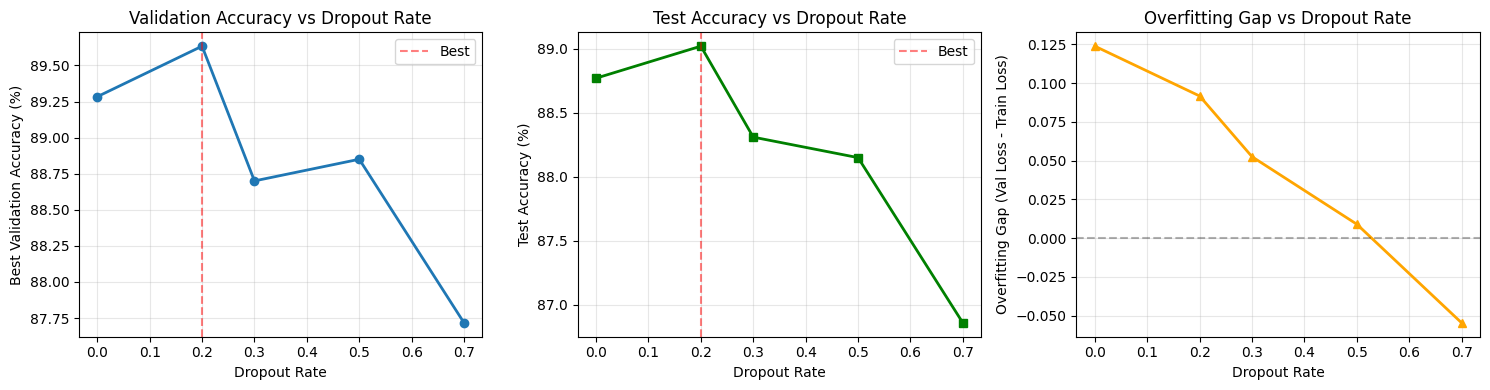


💡 Recommendations:
   ✓ Optimal dropout rate: 0.2
   ✓ Dropout is helping! Sweet spot around 0.2


In [39]:
# Visualize dropout experiments results
import pandas as pd

# Create DataFrame
df_results = pd.DataFrame(results)
print("\n📊 Dropout Rate Experiments Summary")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Find best configurations
best_val = df_results.loc[df_results['best_val_acc'].idxmax()]
best_test = df_results.loc[df_results['test_acc'].idxmax()]

print(f"\n🏆 Best Validation Accuracy: {best_val['best_val_acc']:.2f}% (dropout={best_val['dropout_rate']})")
print(f"🏆 Best Test Accuracy: {best_test['test_acc']:.2f}% (dropout={best_test['dropout_rate']})")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Validation Accuracy vs Dropout
axes[0].plot(df_results['dropout_rate'], df_results['best_val_acc'], marker='o', linewidth=2)
axes[0].set_xlabel('Dropout Rate')
axes[0].set_ylabel('Best Validation Accuracy (%)')
axes[0].set_title('Validation Accuracy vs Dropout Rate')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_val['dropout_rate'], color='r', linestyle='--', alpha=0.5, label='Best')
axes[0].legend()

# Plot 2: Test Accuracy vs Dropout
axes[1].plot(df_results['dropout_rate'], df_results['test_acc'], marker='s', linewidth=2, color='green')
axes[1].set_xlabel('Dropout Rate')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy vs Dropout Rate')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=best_test['dropout_rate'], color='r', linestyle='--', alpha=0.5, label='Best')
axes[1].legend()

# Plot 3: Overfitting Gap vs Dropout
overfitting_gap = df_results['final_val_loss'] - df_results['final_train_loss']
axes[2].plot(df_results['dropout_rate'], overfitting_gap, marker='^', linewidth=2, color='orange')
axes[2].set_xlabel('Dropout Rate')
axes[2].set_ylabel('Overfitting Gap (Val Loss - Train Loss)')
axes[2].set_title('Overfitting Gap vs Dropout Rate')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Recommendations
print(f"\n💡 Recommendations:")
if best_val['dropout_rate'] == best_test['dropout_rate']:
    print(f"   ✓ Optimal dropout rate: {best_val['dropout_rate']}")
else:
    print(f"   ⚠️ Validation suggests: {best_val['dropout_rate']}, Test suggests: {best_test['dropout_rate']}")
    print(f"   → Consider: {(best_val['dropout_rate'] + best_test['dropout_rate']) / 2}")

if df_results['test_acc'].iloc[0] == max(df_results['test_acc']):
    print(f"   ⚠️ No dropout (0.0) performs best - model may not be overfitting much")
elif df_results['test_acc'].iloc[-1] == max(df_results['test_acc']):
    print(f"   ⚠️ Highest dropout ({dropout_rates_to_test[-1]}) performs best - try even higher values")
else:
    print(f"   ✓ Dropout is helping! Sweet spot around {best_test['dropout_rate']}")